In [1]:
import os 
import subprocess 
from pathlib import Path
from shutil import copyfile
from astropy.io import fits
#always run this cell first

In [2]:
#Utilities for running the code in this repo.

def run_log(cmd, logname=None, cwd=None, show_tail=3, check=True):

    import subprocess
    from pathlib import Path
    from datetime import datetime

    current_folder_path = Path.cwd()

    Path("logs").mkdir(exist_ok=True)

    if logname is None:
        logname = cmd[0]

    logpath = Path("logs") / f"{logname}.log"

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd=cwd
    )
    
    output = result.stdout.strip()

    # ✅ only create log if there is real output
    if output:
        with open(logpath, "w") as f:
            f.write(output)
        print(f"Saved → {logpath}")

        for line in output.splitlines()[-show_tail:]:
            print("  ", line)
    else:
        pass

    if check and result.returncode != 0:
        raise RuntimeError(f"{cmd[0]} failed. See {logpath}")

    return result






In [3]:
def plot_evt(evt_file, emin=500, emax=7000, bins=250):

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from astropy.io import fits


    # open event file
    with fits.open(evt_file) as f:
        d = f[1].data

    x = d["X"]
    y = d["Y"]
    e = d["ENERGY"]

    # select energy band
    mask = (e >= emin) & (e <= emax)

    x = x[mask]
    y = y[mask]

    # define detector limits (important!)
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    # convert events → image
    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[[xmin, xmax], [ymin, ymax]]
    )

    # plot
    plt.figure(figsize=(6,5))

    plt.imshow(
        H.T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        norm=LogNorm()
    )

    plt.colorbar(label="counts")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Brightness Map")

    plt.show()

In [4]:
current_folder_path = os.getcwd()
data_folder_path = os.path.join(current_folder_path, 'data')

obs_id = []

for i in os.listdir(data_folder_path):  #test run to check if the code is working fine. It will print the name of the files in the data folder.
    obs_id.append(i.split(' ')[0]) #using space to split as spaces are present in the file names and we only want the obs_id which is the first part of the file name. 

print(obs_id)

['16645', '16635', '16634', '16627', '16633', '16142', '16626', '16464', '16143']


In [5]:
for i in obs_id:
    indir = os.path.join(data_folder_path, i)
    outdir = os.path.join(current_folder_path, 'output', i)
    os.makedirs(outdir, exist_ok=True)
   

    cmd = [  #subprocess is useful as if it encounters an error it will automatically stop the execution of the code and will show the error message in the terminal. Hence useful for loop and debuging.
        "chandra_repro",
        f"indir={indir}",
        f"outdir={outdir}",
        "verbose=1",
        "clobber=yes"
    ]

    run_log(cmd, logname=f"chandra_repro_{i}", cwd=current_folder_path)

Saved → logs/chandra_repro_16645.log
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16645/axaff16645N003_VV001_vv2.pdf
   
   The data have been reprocessed.
   Start your analysis with the new products in
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16645
   
Saved → logs/chandra_repro_16635.log
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16635/axaff16635N002_VV001_vv2.pdf
   
   The data have been reprocessed.
   Start your analysis with the new products in
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16635
   
Saved → logs/chandra_repro_16634.log
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16634/axaff16634N002_VV001_vv2.pdf
   
   The data have been reprocessed.
   Start your analysis with the new products in
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16634
   
Saved → logs/chandra_repro_16627.log
   /home/farhana/Desktop/mimic/brightnessmap_folder/output/16627/axaff16627N003_VV001_vv2.pdf
   
   T

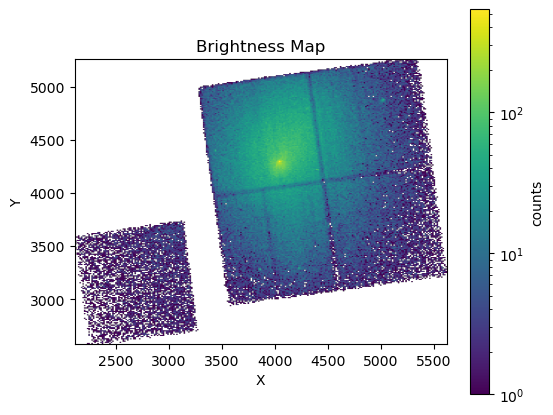

In [8]:
brightness_map('/home/farhana/Desktop/mimic/brightnessmap_folder/output/16143/acisf16143_repro_evt2.fits')

In [14]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    bpix = os.path.join(repro_dir, f"acisf{i}_repro_bpix1.fits")

    subprocess.run(["punlearn", "ardlib"], check=True, cwd=str(repro_dir))
    cmd = ["acis_set_ardlib", str(bpix)]
    run_log(cmd, logname=f"acis_set_ardlib_{i}", cwd=repro_dir)


Saved → logs/acis_set_ardlib_16645.log
     AXAF_ACIS4_BADPIX_FILE -> CALDB
     AXAF_ACIS5_BADPIX_FILE -> CALDB
     AXAF_ACIS6_BADPIX_FILE -> CALDB
     AXAF_ACIS7_BADPIX_FILE -> CALDB
     AXAF_ACIS8_BADPIX_FILE -> CALDB
     AXAF_ACIS9_BADPIX_FILE -> CALDB
Saved → logs/acis_set_ardlib_16635.log
     AXAF_ACIS4_BADPIX_FILE -> CALDB
     AXAF_ACIS5_BADPIX_FILE -> CALDB
     AXAF_ACIS6_BADPIX_FILE -> /home/farhana/Desktop/mimic/brightnessmap_folder/output/16635/acisf16635_repro_bpix1.fits[BADPIX6]
     AXAF_ACIS7_BADPIX_FILE -> CALDB
     AXAF_ACIS8_BADPIX_FILE -> CALDB
     AXAF_ACIS9_BADPIX_FILE -> CALDB
Saved → logs/acis_set_ardlib_16634.log
     AXAF_ACIS4_BADPIX_FILE -> CALDB
     AXAF_ACIS5_BADPIX_FILE -> CALDB
     AXAF_ACIS6_BADPIX_FILE -> /home/farhana/Desktop/mimic/brightnessmap_folder/output/16634/acisf16634_repro_bpix1.fits[BADPIX6]
     AXAF_ACIS7_BADPIX_FILE -> CALDB
     AXAF_ACIS8_BADPIX_FILE -> CALDB
     AXAF_ACIS9_BADPIX_FILE -> CALDB
Saved → logs/acis_set_ardlib_16

In [18]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)

    evt2_path = repro_path / f"acisf{i}_repro_evt2.fits"
    outroot = repro_path / f"{i}"


    cmd =[
    "fluximage",
    str(evt2_path),
    str(outroot),
    "binsize=1",
    "bands=0.5:7:2.3",
    "clobber=yes"
    ]
    
    run_log(cmd, logname=f"fluximage_{i}", cwd=str(repro_path))

Saved → logs/fluximage_16645.log
    The exposure-corrected image is:
        /home/farhana/Desktop/mimic/brightnessmap_folder/output/16645/16645_0.5-7_flux.img
   
Saved → logs/fluximage_16635.log
    The exposure-corrected image is:
        /home/farhana/Desktop/mimic/brightnessmap_folder/output/16635/16635_0.5-7_flux.img
   
Saved → logs/fluximage_16634.log
    The exposure-corrected image is:
        /home/farhana/Desktop/mimic/brightnessmap_folder/output/16634/16634_0.5-7_flux.img
   
Saved → logs/fluximage_16627.log
    The exposure-corrected image is:
        /home/farhana/Desktop/mimic/brightnessmap_folder/output/16627/16627_0.5-7_flux.img
   
Saved → logs/fluximage_16633.log
    The exposure-corrected image is:
        /home/farhana/Desktop/mimic/brightnessmap_folder/output/16633/16633_0.5-7_flux.img
   
Saved → logs/fluximage_16142.log
    The exposure-corrected image is:
        /home/farhana/Desktop/mimic/brightnessmap_folder/output/16142/16142_0.5-7_flux.img
   
Saved → lo

In [19]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)


    thresh = repro_path / f"{i}_0.5-7_thresh.img"
    psffile = repro_path / f"{i}_0.5-7.psf"

    subprocess.run(["punlearn", "mkpsfmap"], check=True, cwd=str(repro_path))
    cmd =[
        "mkpsfmap",
        f"infile={thresh}",                 
        f"outfile={psffile}",
        "energy=2.3",
    "ecf=0.9",
    "clobber=yes"
    ]
    run_log(cmd, logname=f"mkpsfmap_{i}", cwd=str(repro_path))  

Saved → logs/mkpsfmap_16645.log
Saved → logs/mkpsfmap_16635.log
Saved → logs/mkpsfmap_16634.log
Saved → logs/mkpsfmap_16627.log
Saved → logs/mkpsfmap_16633.log
Saved → logs/mkpsfmap_16142.log
Saved → logs/mkpsfmap_16626.log
Saved → logs/mkpsfmap_16464.log
Saved → logs/mkpsfmap_16143.log


In [23]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)

    thresh = repro_path / f"{i}_0.5-7_thresh.img"
    psffile = repro_path / f"{i}_0.5-7.psf"
    exp = repro_path / f"{i}_0.5-7_thresh.expmap"
    outfile = repro_path / f"{i}_0.5-7_src.fits"
    regfile = repro_path / f"{i}_0.5-7_src.reg"
    

    subprocess.run(["punlearn", "wavdetect"], check=True, cwd=str(repro_path))

    cmd = [

        "wavdetect",
        f"infile={thresh}",
        f"psffile={psffile}",
        f"expfile={exp}",
        f"outfile={outfile}",
        f"scellfile={i}_scell_0.5-7.fits",
        f"imagefile={i}_imgfile_0.5-7.img",
        f"defnbkgfile={i}_defnbkg_0.5-7.fits",
        f"regfile={regfile}",
        "scales=1 2 4 8 16 32",   # single argument containing the scale list
        "maxiter=3",
        "sigthresh=5e-6",
        "ellsigma=5.0",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"wavdetect_{i}", cwd=str(repro_path))


Saved → logs/wavdetect_16645.log
Saved → logs/wavdetect_16635.log
Saved → logs/wavdetect_16634.log
Saved → logs/wavdetect_16627.log
Saved → logs/wavdetect_16633.log
Saved → logs/wavdetect_16142.log
Saved → logs/wavdetect_16626.log
Saved → logs/wavdetect_16464.log
Saved → logs/wavdetect_16143.log


In [25]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    nosrc_evt = repro_path / f"{i}_0.5-7_nosrc_evt.fits"
    reg_name = repro_path / f"{i}_0.5-7_src.reg"
    evt2_name = repro_path / f"acisf{i}_repro_evt2.fits"
    

    subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(repro_path))

    cmd = [
        "dmcopy",
        f"{evt2_name}[exclude sky=region({reg_name})]",
        nosrc_evt,
        "option=all",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"dmcopy_{i}", cwd=str(repro_path))

(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)


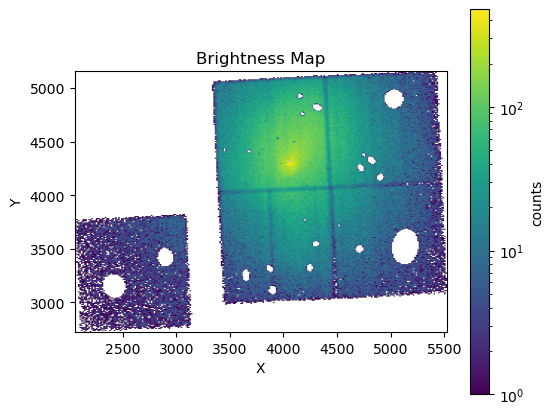

In [ ]:
plot_evt('/home/farhana/Desktop/mimic/brightnessmap_folder/output/16142/16142_0.5-7_nosrc_evt.fits')

In [27]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    nosrc_evt = repro_path / f"{i}_0.5-7_nosrc_evt.fits"
    nosrc_evtfilter = repro_path / f"{i}_0.5-7_nosrc_evtfilter.fits"

    subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(repro_path))

    cmd = [
        "dmcopy",
        f"{nosrc_evt}[energy=500:7000]",
        nosrc_evtfilter,
        "option=all",
        "clobber=yes"
    ]

    run_log(cmd, logname=f"dmcopy_{i}", cwd=str(repro_path))

(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)


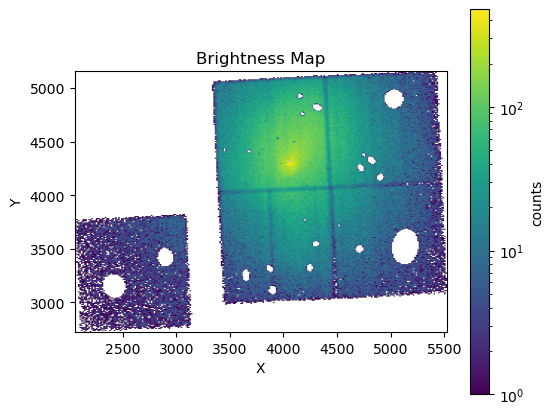

In [ ]:
plot_evt('/home/farhana/Desktop/mimic/brightnessmap_folder/output/16142/16142_0.5-7_nosrc_evtfilter.fits')

In [28]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    nosrc_evtfilter = repro_path / f"{i}_0.5-7_nosrc_evtfilter.fits"
    lc_out = repro_path / f"{i}_0.5-7_lc_out"

    
    subprocess.run(["punlearn", "dmextract"], check=True, cwd=str(repro_path))

    cmd = [
        "dmextract",
        f"{nosrc_evtfilter}[bin time=::259.28]",
        lc_out,
        "opt=ltc1",
        "clobber=yes"
    ]

    run_log(cmd, logname=f"dmextract_{i}", cwd=str(repro_path))

(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)


In [31]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    lc_out = repro_path / f"{i}_0.5-7_lc_out"
    gti = repro_path / f"{i}_0.5-7_gti"

    subprocess.run(["punlearn", "deflare"], check=True, cwd=str(repro_path))

    cmd = [
        "deflare",
        f"infile={lc_out}",
        f"outfile={gti}",
        "method=clean"
    ]
    run_log(cmd, logname=f"deflare_{i}", cwd=str(repro_path))

Saved → logs/deflare_16645.log
   Creating GTI file
   Created: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16645/16645_0.5-7_gti
   Light curve cleaned using the lc_clean routine.
Saved → logs/deflare_16635.log
   Creating GTI file
   Created: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16635/16635_0.5-7_gti
   Light curve cleaned using the lc_clean routine.
Saved → logs/deflare_16634.log
   Creating GTI file
   Created: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16634/16634_0.5-7_gti
   Light curve cleaned using the lc_clean routine.
Saved → logs/deflare_16627.log
   Creating GTI file
   Created: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16627/16627_0.5-7_gti
   Light curve cleaned using the lc_clean routine.
Saved → logs/deflare_16633.log
   Creating GTI file
   Created: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16633/16633_0.5-7_gti
   Light curve cleaned using the lc_clean routine.
Saved → logs/deflare_16142.log
   C

In [32]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)

    subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(repro_path))
    evt2 = repro_path / f"acisf{i}_repro_evt2.fits"
    gti = repro_path / f"{i}_0.5-7_gti"
    clean_evt = repro_path / f"{i}_0.5-7_clean_evt.fits"

    cmd = [
        "dmcopy",
        f"{evt2}[@{gti}]",
        f"outfile={clean_evt}",
        "option=all",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"dmcopy_{i}", cwd=str(repro_path))

(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)
(no output)


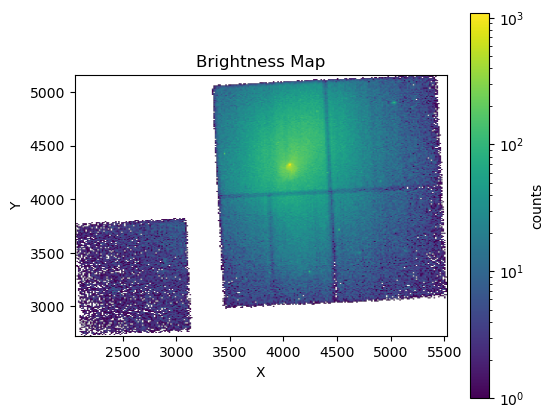

In [ ]:
plot_evt('/home/farhana/Desktop/mimic/brightnessmap_folder/output/16142/16142_0.5-7_clean_evt.fits')

In [18]:
for i in obs_id:
    current_folder_path = os.getcwd()
    data_folder_path = os.path.join(current_folder_path, 'data', i)
    secondary_folder_path = Path("data") / str(i) / "secondary"
    evt1_file = next(secondary_folder_path.glob("*evt1.fits"))

    cmd = [
        "dmkeypar",
        f"infile={evt1_file.name}",
        "keyword=DETNAM",
        "echo=yes"
    ]
    
    run_log(cmd, logname=f"dmkeypar_{i}", cwd=str(secondary_folder_path))

Saved → logs/dmkeypar_16645.log
   ACIS-0123
Saved → logs/dmkeypar_16635.log
   ACIS-01236
Saved → logs/dmkeypar_16634.log
   ACIS-01236
Saved → logs/dmkeypar_16627.log
   ACIS-01236
Saved → logs/dmkeypar_16633.log
   ACIS-01236
Saved → logs/dmkeypar_16142.log
   ACIS-01236
Saved → logs/dmkeypar_16626.log
   ACIS-01236
Saved → logs/dmkeypar_16464.log
   ACIS-0123
Saved → logs/dmkeypar_16143.log
   ACIS-01236


In [5]:
for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"
    analysis_path.mkdir(exist_ok=True)
    

    for ccd in [0,1,2,3]:
        cmd = [
            "dmcopy",
            f"acisf{i}_repro_evt2.fits[ccd_id={ccd}]",
            f"analysis/acis_ccd{ccd}.fits",
            "clobber=yes"
        ]
        run_log(cmd, logname=f"dmcopy_{i}_ccd{ccd}", cwd=str(repro_path))

KeyboardInterrupt: 

In [21]:
for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"
    

    subprocess.run(
    "ls acis_ccd*.fits > acisI.lis",
    shell=True,
    cwd=str(analysis_path)
    )

    cmd = [
        "dmmerge",
        f"infile=@{analysis_path}/acisI.lis[subspace -expno]",
        f"outfile={analysis_path}/acisI.fits",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"dmmerge_{i}", cwd=str(analysis_path)) 

In [ ]:
from pathlib import Path
import subprocess, shutil

for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"
    
    for ccd in [0,1,2,3]:
        acis_ccd = analysis_path / f"acis_ccd{ccd}.fits"
         
       # run the lookup but keep logs and only print last few lines
        logname = f"{i}_ccd{ccd}_acis_bkgrnd_lookup"
        res = run_log(["acis_bkgrnd_lookup", f"infile={acis_ccd.name}"],
                      logname=logname,
                      cwd=str(analysis_path),
                      show_tail=5,
                      check=False) 
        

        if res.returncode != 0:
            # print(f"[{i}] CCD{ccd}: lookup command failed (rc={res.returncode}) -> see logs/{logname}.log")
            continue
        
        out_lines = [ln.strip() for ln in res.stdout.splitlines() if ln.strip()]
        

        caldb_path = out_lines[-1]                     # the matching CALDB background path
        dst = analysis_path / f"back_ccd{ccd}.fits"    # destination to write immediately

        try:
            shutil.copy(caldb_path, dst)
            #print(f"[{i}] CCD{ccd}: copied {caldb_path} -> {dst.name}")
        except Exception as e:
            print(f"[{i}] CCD{ccd}: copy failed -> {e}")

Saved → logs/16645_ccd0_acis_bkgrnd_lookup.log
   /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/bkgrnd/acis0iD2012-01-01bkgrnd_ctiN0002.fits
[16645] CCD0: copied /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/bkgrnd/acis0iD2012-01-01bkgrnd_ctiN0002.fits -> back_ccd0.fits
Saved → logs/16645_ccd1_acis_bkgrnd_lookup.log
   /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/bkgrnd/acis1iD2012-01-01bkgrnd_ctiN0002.fits
[16645] CCD1: copied /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/bkgrnd/acis1iD2012-01-01bkgrnd_ctiN0002.fits -> back_ccd1.fits
Saved → logs/16645_ccd2_acis_bkgrnd_lookup.log
   /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/bkgrnd/acis2iD2012-01-01bkgrnd_ctiN0002.fits
[16645] CCD2: copied /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/bkgrnd/acis2iD2012-01-01bkgrnd_ctiN0002.fits -> back_ccd2.fits
Saved → logs/16645_ccd3_acis_bkgrnd_lookup.log
   /home/farhana/miniforge3/envs/ciao/CALDB/data/chandra/acis/

In [27]:
import shutil
from pathlib import Path

#succesfully copied the asol files to the analysis folder. This is important as the reproject step needs the asol files to reproject the background files to match the observation files. If the asol files are not present, the reproject step will fail and we won't be able to proceed with the analysis.
for i in obs_id:

    current_folder_path = os.getcwd()
    data_folder_path = os.path.join(current_folder_path, 'data')
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"


    src = repro_path / f"acisf{i}_asol1.lis"
    dst = analysis_path / "pcad_asol1.lis"

    shutil.copy(src, dst)

    print("Copied:", dst)

Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16645/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16635/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16634/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16627/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16633/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16142/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16626/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16464/analysis/pcad_asol1.lis
Copied: /home/farhana/Desktop/mimic/brightnessmap_folder/output/16143/analysis/pcad_asol1.lis


In [ ]:
import subprocess
from pathlib import Path

#reprojecting the background files to match the observation files. This is important as the background files need to be in the same coordinate system as the observation files for accurate analysis. If the background files are not reprojected, we might get inaccurate results when we subtract the background from the observation.
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"


    aspect_file = analysis_path / "pcad_asol1.lis"
    match_evt   = repro_path / f"acisf{i}_repro_evt2.fits"

    for ccd in [0,1,2,3]:

        back = analysis_path / f"back_ccd{ccd}.fits"

        if not back.exists():
            continue

        subprocess.run(["punlearn","reproject_events"], check=True, cwd=str(analysis_path))

        cmd = [
            "reproject_events",
            f"infile={back.name}",
            f"outfile=back_reproj_ccd{ccd}.fits",
            f"aspect=@{aspect_file.name}",
            f"match={match_evt}",
            "random=0",
            "clobber=yes",
            "mode=h"
        ]

        run_log(cmd, logname=f"reprop('/home/farhaject_events_{i}_ccd{ccd}", cwd=str(analysis_path))
        #print(f"{i} CCD{ccd} done")

In [ ]:
#Puts all the reprojected background files in a master list file called back.lis. This is important as the back.lis file is used in the next step to merge all the reprojected background files into a single file that can be used for analysis. If the back.lis file is not created, we won't be able to proceed with the analysis as we won't have the merged background file.

current_folder_path = Path.cwd()
repro_path = current_folder_path / "output" 

all_files = []

for i in obs_id:
    
    analysis_path = repro_path / i / "analysis"
    all_files.extend(sorted(analysis_path.glob("back_reproj_ccd*.fits")))

    master_list = repro_path / "back.lis"
    with open(master_list, "w") as f:
        for file in all_files:
            f.write(str(file) + "\n")


   

In [18]:
merged_back = repro_path / "merged_background.fits"

subprocess.run(["punlearn", "dmmerge"], check=True, cwd=str(repro_path))

cmd = [
    "dmmerge",
    f"infile=@{master_list.name}",
    f"outfile={merged_back.name}",
    "clobber=yes"
]

run_log(cmd, logname="dmmerge_merged_background", cwd=str(repro_path))

Saved → logs/dmmerge_merged_background.log
   omit - RA_PNT values different more than 0.000300
   omit - ROLL_PNT values different more than 1.000000
   omit - SIM_Z values different more than 0.100000


CompletedProcess(args=['dmmerge', 'infile=@back.lis', 'outfile=merged_background.fits', 'clobber=yes'], returncode=0, stdout='omit - DEC_NOM values different more than 0.000300\nomit - DEC_PNT values different more than 0.000300\nwarning: DETNAM has different value...Merged...\nomit - RA_NOM values different more than 0.000300\nomit - RA_PNT values different more than 0.000300\nomit - ROLL_PNT values different more than 1.000000\nomit - SIM_Z values different more than 0.100000\n')

In [15]:
current_folder_path = Path.cwd()

clean_list_path = current_folder_path / "output" / "clean_evt.list"

with open(clean_list_path, "w") as f:
    for i in obs_id:
        
        clean_evt = ( current_folder_path / "output" / i / f"{i}_0.5-7_clean_evt.fits" )
        f.write(str(clean_evt) + "\n")

print("List written to:", clean_list_path)

List written to: /home/farhana/Desktop/mimic/brightnessmap_folder/output/clean_evt.list


In [19]:
current_folder_path = Path.cwd()

repro_path = current_folder_path / "output"

merge_dir = repro_path / "merged_obs"
merge_dir.mkdir(exist_ok=True)

clean_list_path = repro_path / "clean_evt.list"

outroot = merge_dir / "merged"

subprocess.run(["punlearn", "merge_obs"], check=True)

cmd = [
    "merge_obs",
    f"@{clean_list_path}",
    str(outroot),
    "bin=1",
    "bands=broad",
    "clobber=yes"
]
run_log(cmd, logname="merge_obs", cwd=str(repro_path))

Saved → logs/merge_obs.log
         the DEC_NOM keyword varies by 0.0110 (limit is 0.0003)
         the ROLL_NOM keyword varies by 5.0 (limit is 1.0)
         the SIM_Z keyword varies by 1.5 (limit is 0.1)


CompletedProcess(args=['merge_obs', '@/home/farhana/Desktop/mimic/brightnessmap_folder/output/clean_evt.list', '/home/farhana/Desktop/mimic/brightnessmap_folder/output/merged_obs/merged', 'bin=1', 'bands=broad', 'clobber=yes'], returncode=0, stdout='Running merge_obs\nVersion: 05 November 2021\n\nVerifying 9 observations.\nUsing CSC ACIS broad science energy band.\nCalculating new tangent point.\nNew tangent point: RA=17h 12m 26.147s Dec=-23d 23\' 57.37"\n\nObservations to be reprojected:\n\n  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  \n                   (ks)                (mm)    (K)   (\')  (deg)\n---------------------------------------------------------------\n1 16142 2014-07-01  32.7 ACIS-01236  -226.748 153.6  < 3"  +100\n2 16626 2014-07-03  30.8 ACIS-01236  -226.748 153.6  < 3"   +78\n3 16627 2014-07-05  34.6 ACIS-01236  -226.748 153.6   0.1  +134\n4 16634 2014-07-11  22.4 ACIS-01236  -226.286 153.9   0.4   -14\n5 16635 2014-07-12  18.9 ACIS-01236  -226.286 1